In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import platform
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':  # macOS
    plt.rcParams['font.family'] = 'AppleGothic'
else:  # Linux
    plt.rcParams['font.family'] = 'NanumGothic'

# 마이너스 기호 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False
type1_df = pd.read_csv('/Users/jisoyun/Desktop/sparta_python/심화 프로젝트/hotsix/data/df_clean_Type1.csv')
type1_df.columns = type1_df.columns.str.strip()

In [18]:
type1_df.columns

Index(['id', 'Product_Type', 'Shot', 'Velocity_1', 'Velocity_2', 'Velocity_3',
       'High_Velocity', 'Cylinder_Pressure', 'Rapid_Rise_Time',
       'Biscuit_Thickness', 'Clamping_Force', 'Cycle_Time',
       'Pressure_Rise_Time', 'Casting_Pressure', 'Spray_Time', 'Spray_1_Time',
       'Spray_2_Time', 'Melting_Furnace_Temp', 'Air_Pressure', 'Coolant_Temp',
       'Coolant_Pressure', 'Factory_Temp', 'Factory_Humidity', 'Pressure_Diff',
       'Defect_Status', 'Defect_Type'],
      dtype='str')

In [19]:
cols = ['Velocity_1', 'Velocity_2', 'Velocity_3', 'High_Velocity']
type1_df['Velocity_minmax'] = type1_df[cols].max(axis=1) - type1_df[cols].min(axis=1)

In [20]:
display(type1_df['Velocity_minmax'])

0       1.9900
1       1.9800
2       1.9720
3       1.9930
4       1.9670
         ...  
2646    2.0525
2647    2.0525
2648    2.0525
2649    2.0525
2650    2.0525
Name: Velocity_minmax, Length: 2651, dtype: float64

In [21]:
type1_df['Velocity_diff_1_2'] = type1_df['Velocity_2'] - type1_df['Velocity_1']
type1_df['Velocity_diff_2_3'] = type1_df['Velocity_3'] - type1_df['Velocity_2']
type1_df['Velocity_diff_3_high'] = type1_df['High_Velocity'] - type1_df['Velocity_3']
type1_df['Pressure_Diff_ratio'] = type1_df['Pressure_Diff'] / type1_df['Cylinder_Pressure']


In [22]:
type1_df.columns

Index(['id', 'Product_Type', 'Shot', 'Velocity_1', 'Velocity_2', 'Velocity_3',
       'High_Velocity', 'Cylinder_Pressure', 'Rapid_Rise_Time',
       'Biscuit_Thickness', 'Clamping_Force', 'Cycle_Time',
       'Pressure_Rise_Time', 'Casting_Pressure', 'Spray_Time', 'Spray_1_Time',
       'Spray_2_Time', 'Melting_Furnace_Temp', 'Air_Pressure', 'Coolant_Temp',
       'Coolant_Pressure', 'Factory_Temp', 'Factory_Humidity', 'Pressure_Diff',
       'Defect_Status', 'Defect_Type', 'Velocity_minmax', 'Velocity_diff_1_2',
       'Velocity_diff_2_3', 'Velocity_diff_3_high', 'Pressure_Diff_ratio'],
      dtype='str')

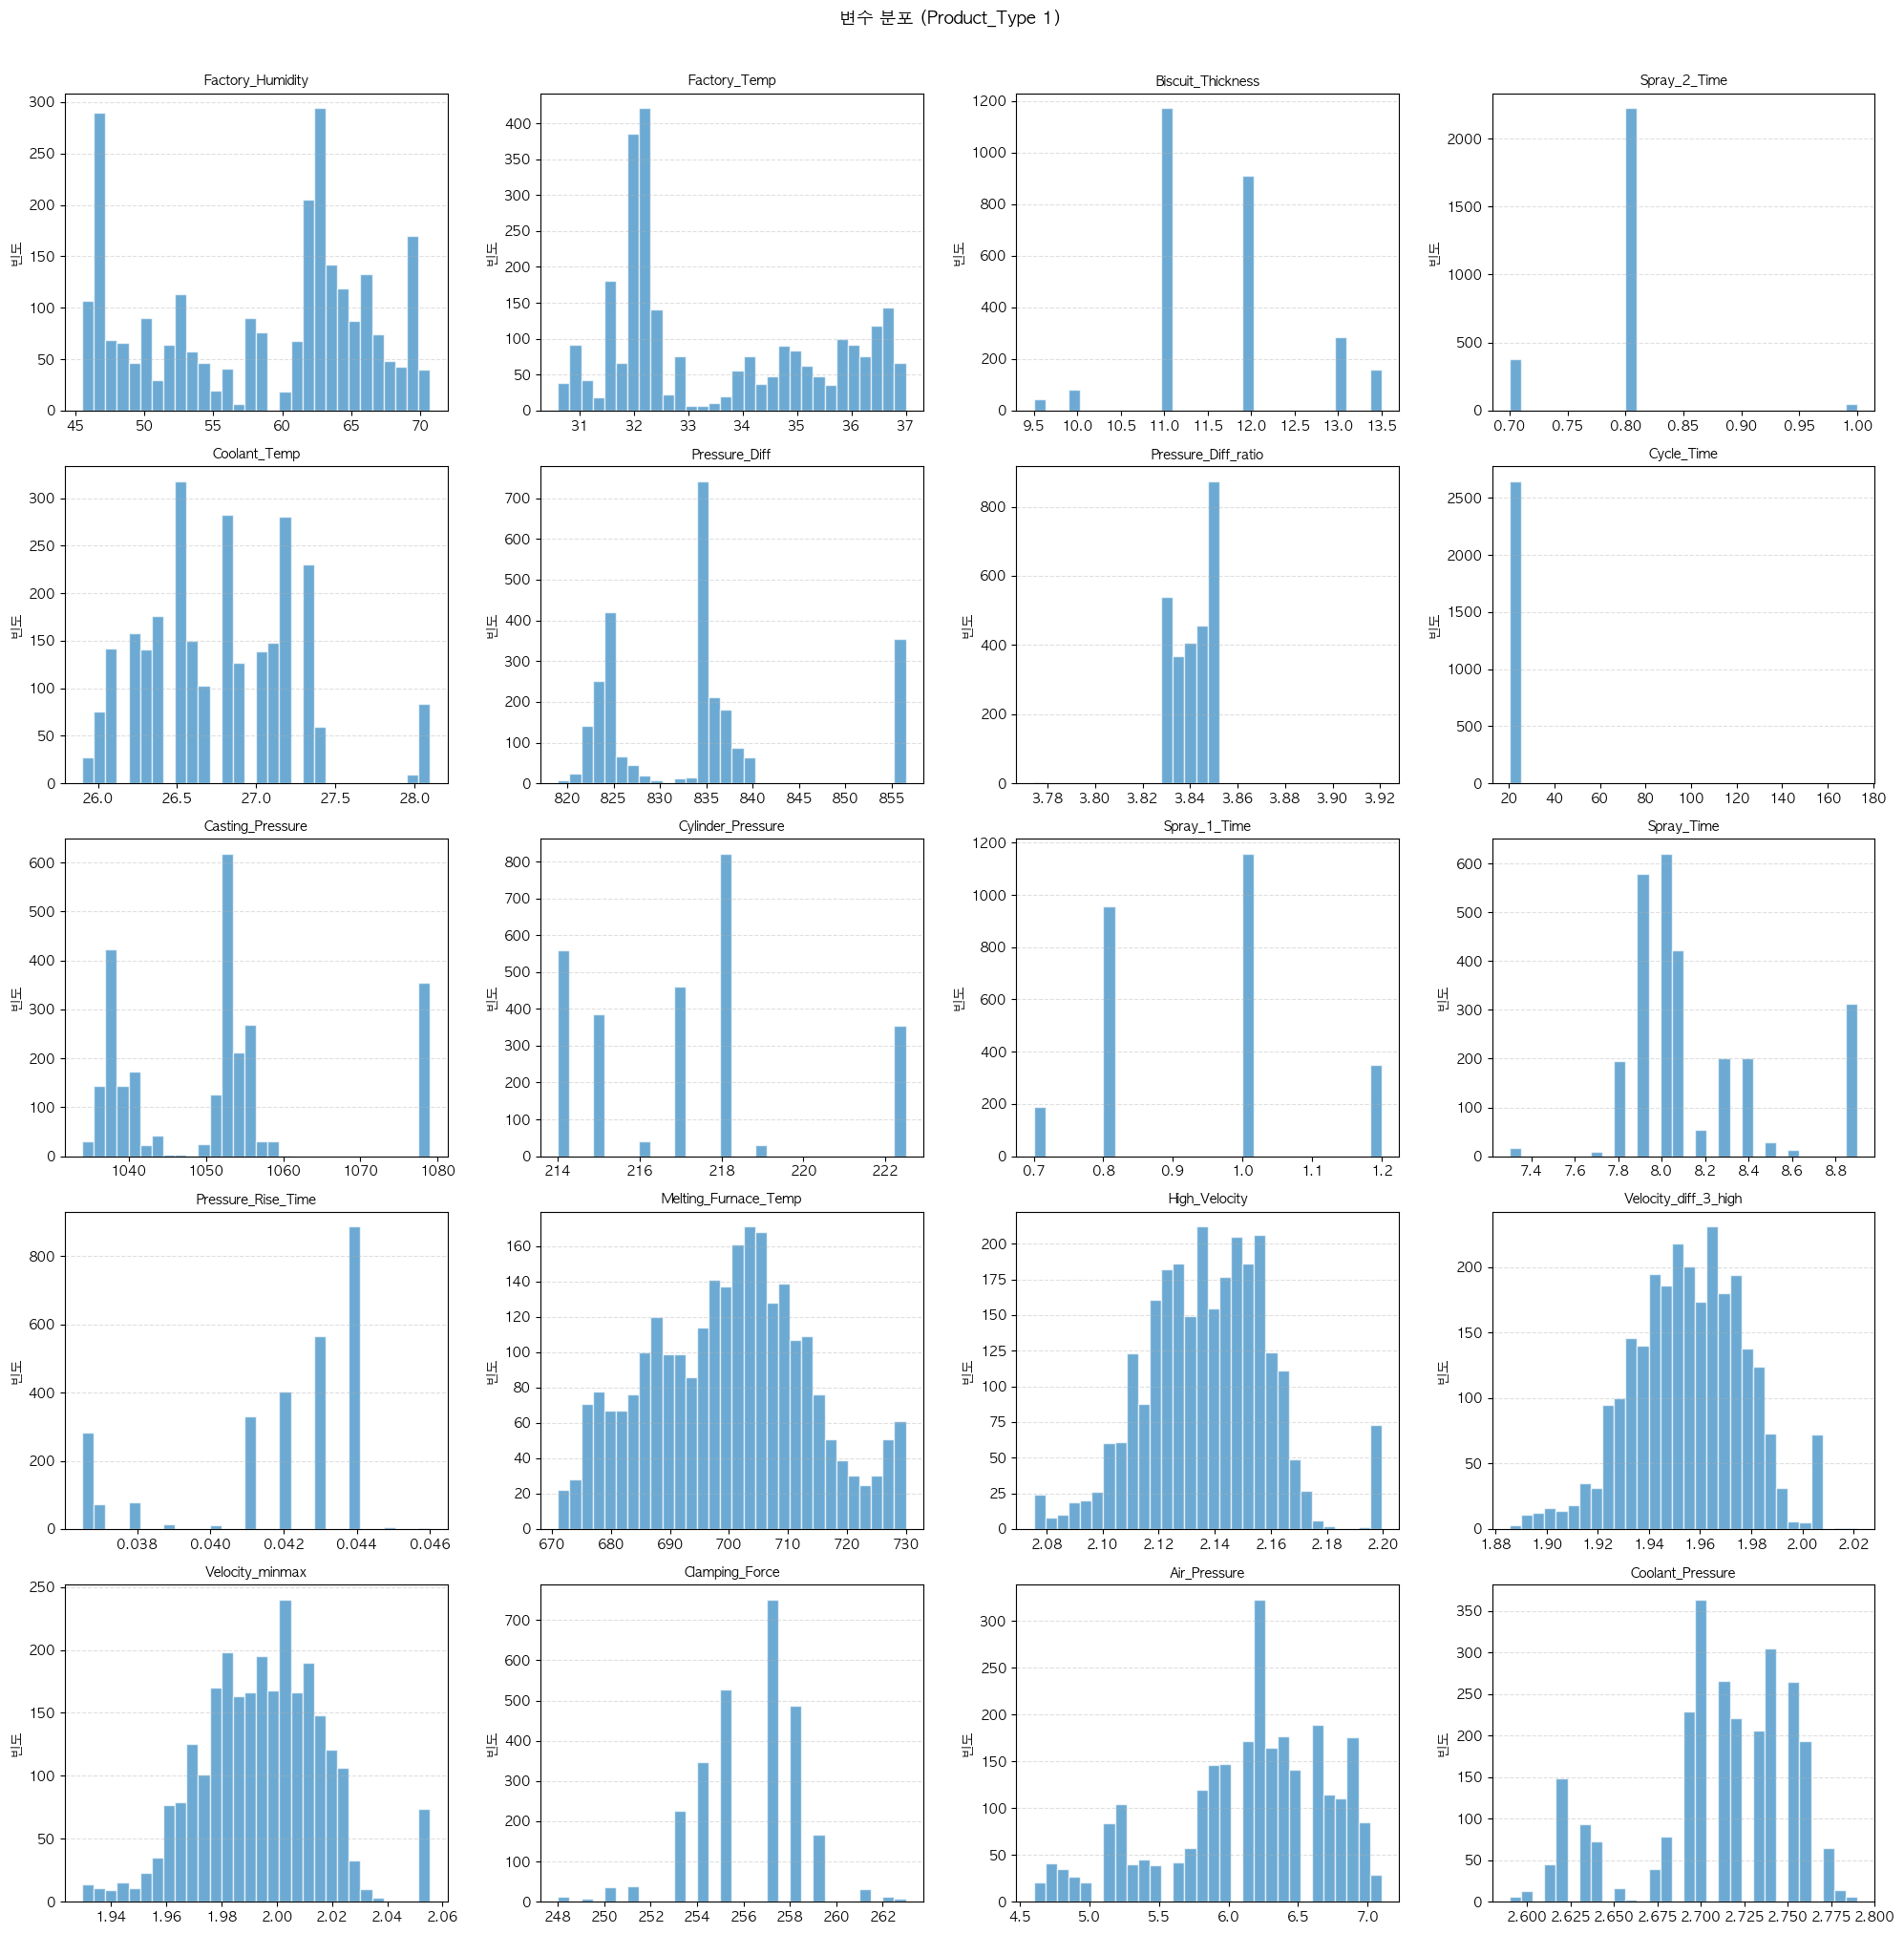

In [23]:
import math

final_vars = [
    'Factory_Humidity',
    'Factory_Temp',
    'Biscuit_Thickness',
    'Spray_2_Time',
    'Coolant_Temp',
    'Pressure_Diff',
    'Pressure_Diff_ratio',
    'Cycle_Time',
    'Casting_Pressure',
    'Cylinder_Pressure',
    'Spray_1_Time',
    'Spray_Time',
    'Pressure_Rise_Time',
    'Melting_Furnace_Temp',
    'High_Velocity',
    'Velocity_diff_3_high',
    'Velocity_minmax',
    'Clamping_Force',
    'Air_Pressure',
    'Coolant_Pressure',
]
# 변수 히스토그램
num_cols = [col for col in final_vars if type1_df[col].dtype in ['int64', 'float64']]

n_cols = 4
n_rows = math.ceil(len(num_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 4*n_rows))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].hist(type1_df[col].dropna(), bins=30, color='#2E86C1', alpha=0.7, edgecolor='white')
    axes[i].set_title(col, fontsize=10, fontweight='bold')
    axes[i].set_ylabel('빈도')
    axes[i].grid(axis='y', linestyle='--', alpha=0.4)

for j in range(len(num_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('변수 분포 (Product_Type 1)', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

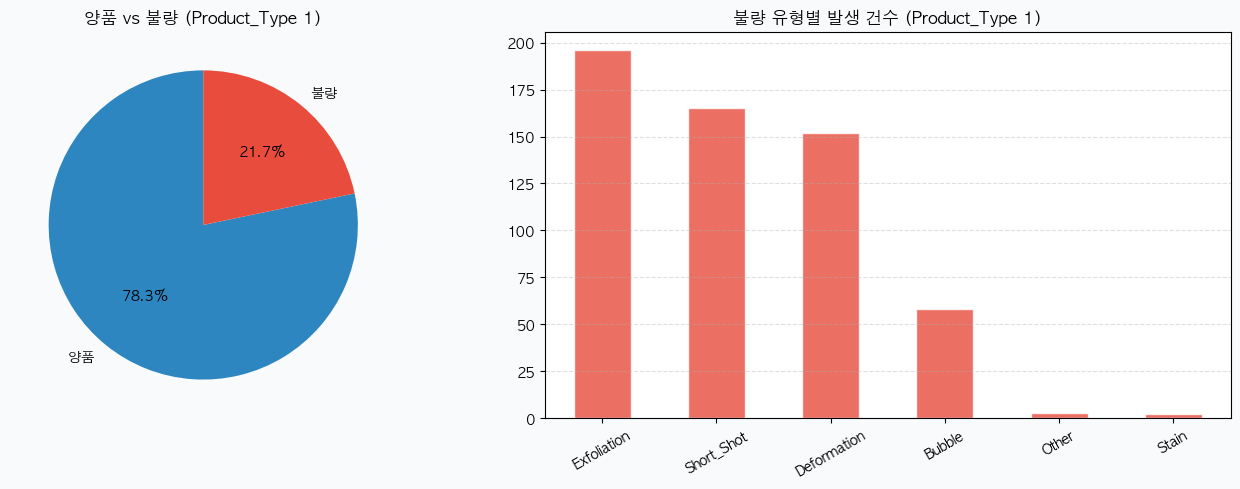

In [24]:
# 불량 분포 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 5), facecolor='#F8FAFB')

# 파이 차트
sizes = type1_df['Defect_Status'].value_counts().sort_index()
axes[0].pie(sizes, labels=['양품', '불량'], autopct='%1.1f%%',
            colors=['#2E86C1', '#E74C3C'], startangle=90)
axes[0].set_title(f'양품 vs 불량 (Product_Type 1)', fontweight='bold')

# 불량 유형 바 차트
defect_counts = type1_df[type1_df['Defect_Status']==1]['Defect_Type'].value_counts()
defect_counts.plot(kind='bar', ax=axes[1], color='#E74C3C', alpha=0.8, edgecolor='white')
axes[1].set_title('불량 유형별 발생 건수 (Product_Type 1)', fontweight='bold')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=30)
axes[1].grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

In [25]:
from scipy.stats import spearmanr

exclude_cols = ['Defect_Status', 'Defect_Type', 'id', 'Product_Type']

results = []

for col in type1_df.columns:
    if col in exclude_cols:
        continue
    clean = type1_df[[col, 'Defect_Status']].dropna()
    corr, p = spearmanr(clean[col], clean['Defect_Status'])
    results.append({
        '변수': col,
        '스피어만 상관계수': round(corr, 4),
        'p-value': round(p, 4),
        '절댓값': round(abs(corr), 4)
    })

spearman_df = pd.DataFrame(results).sort_values('절댓값', ascending=False)
print(spearman_df.to_string(index=False))

                  변수  스피어만 상관계수  p-value    절댓값
    Factory_Humidity    -0.2782   0.0000 0.2782
        Factory_Temp     0.2155   0.0000 0.2155
   Biscuit_Thickness    -0.1699   0.0000 0.1699
        Spray_2_Time     0.1669   0.0000 0.1669
       Pressure_Diff    -0.1277   0.0000 0.1277
    Casting_Pressure    -0.1253   0.0000 0.1253
   Cylinder_Pressure    -0.1210   0.0000 0.1210
          Cycle_Time    -0.1204   0.0000 0.1204
 Pressure_Diff_ratio    -0.0992   0.0000 0.0992
  Pressure_Rise_Time     0.0990   0.0000 0.0990
          Spray_Time    -0.0963   0.0000 0.0963
      Clamping_Force     0.0797   0.0000 0.0797
Melting_Furnace_Temp    -0.0770   0.0001 0.0770
        Air_Pressure     0.0730   0.0002 0.0730
       High_Velocity     0.0724   0.0002 0.0724
Velocity_diff_3_high     0.0703   0.0003 0.0703
     Velocity_minmax     0.0674   0.0005 0.0674
   Velocity_diff_1_2    -0.0486   0.0124 0.0486
        Spray_1_Time     0.0485   0.0126 0.0485
    Coolant_Pressure    -0.0424   0.0292

In [26]:
#---------------------
# 1. 정규성 검정
#---------------------
from scipy import stats

target_vars = [
    # 기존
    'Factory_Humidity',
    'Factory_Temp',
    'Biscuit_Thickness',
    'Pressure_Diff',
    'Pressure_Diff_ratio',
    'Pressure_Rise_Time',
    'Spray_Time',
    'Clamping_Force',
    'Air_Pressure',
    'High_Velocity',
    'Coolant_Pressure',
    # 새로 추가
    'Spray_2_Time',
    'Casting_Pressure',
    'Cylinder_Pressure',
    'Cycle_Time',
    'Melting_Furnace_Temp',
    'Spray_1_Time',
    'Coolant_Temp',
    'Velocity_2',
    'Velocity_minmax', 
    'Velocity_diff_1_2',
    'Velocity_diff_2_3', 
    'Velocity_diff_3_high'
]

results = []
for col in target_vars:
    stat, p = stats.shapiro(type1_df[col].dropna())
    results.append({
        '변수': col,
        'W통계량': round(stat, 4),
        'p-value': round(p, 4),
        '정규성': '✅' if p > 0.05 else '❌'
    })

print(pd.DataFrame(results).to_string(index=False))

                  변수   W통계량  p-value 정규성
    Factory_Humidity 0.9064      0.0   ❌
        Factory_Temp 0.8753      0.0   ❌
   Biscuit_Thickness 0.8671      0.0   ❌
       Pressure_Diff 0.8253      0.0   ❌
 Pressure_Diff_ratio 0.8493      0.0   ❌
  Pressure_Rise_Time 0.7748      0.0   ❌
          Spray_Time 0.8200      0.0   ❌
      Clamping_Force 0.9369      0.0   ❌
        Air_Pressure 0.9485      0.0   ❌
       High_Velocity 0.9834      0.0   ❌
    Coolant_Pressure 0.9184      0.0   ❌
        Spray_2_Time 0.4861      0.0   ❌
    Casting_Pressure 0.8321      0.0   ❌
   Cylinder_Pressure 0.8509      0.0   ❌
          Cycle_Time 0.0542      0.0   ❌
Melting_Furnace_Temp 0.9870      0.0   ❌
        Spray_1_Time 0.8428      0.0   ❌
        Coolant_Temp 0.9535      0.0   ❌
          Velocity_2 0.8756      0.0   ❌
     Velocity_minmax 0.9890      0.0   ❌
   Velocity_diff_1_2 0.9556      0.0   ❌
   Velocity_diff_2_3 0.9755      0.0   ❌
Velocity_diff_3_high 0.9944      0.0   ❌


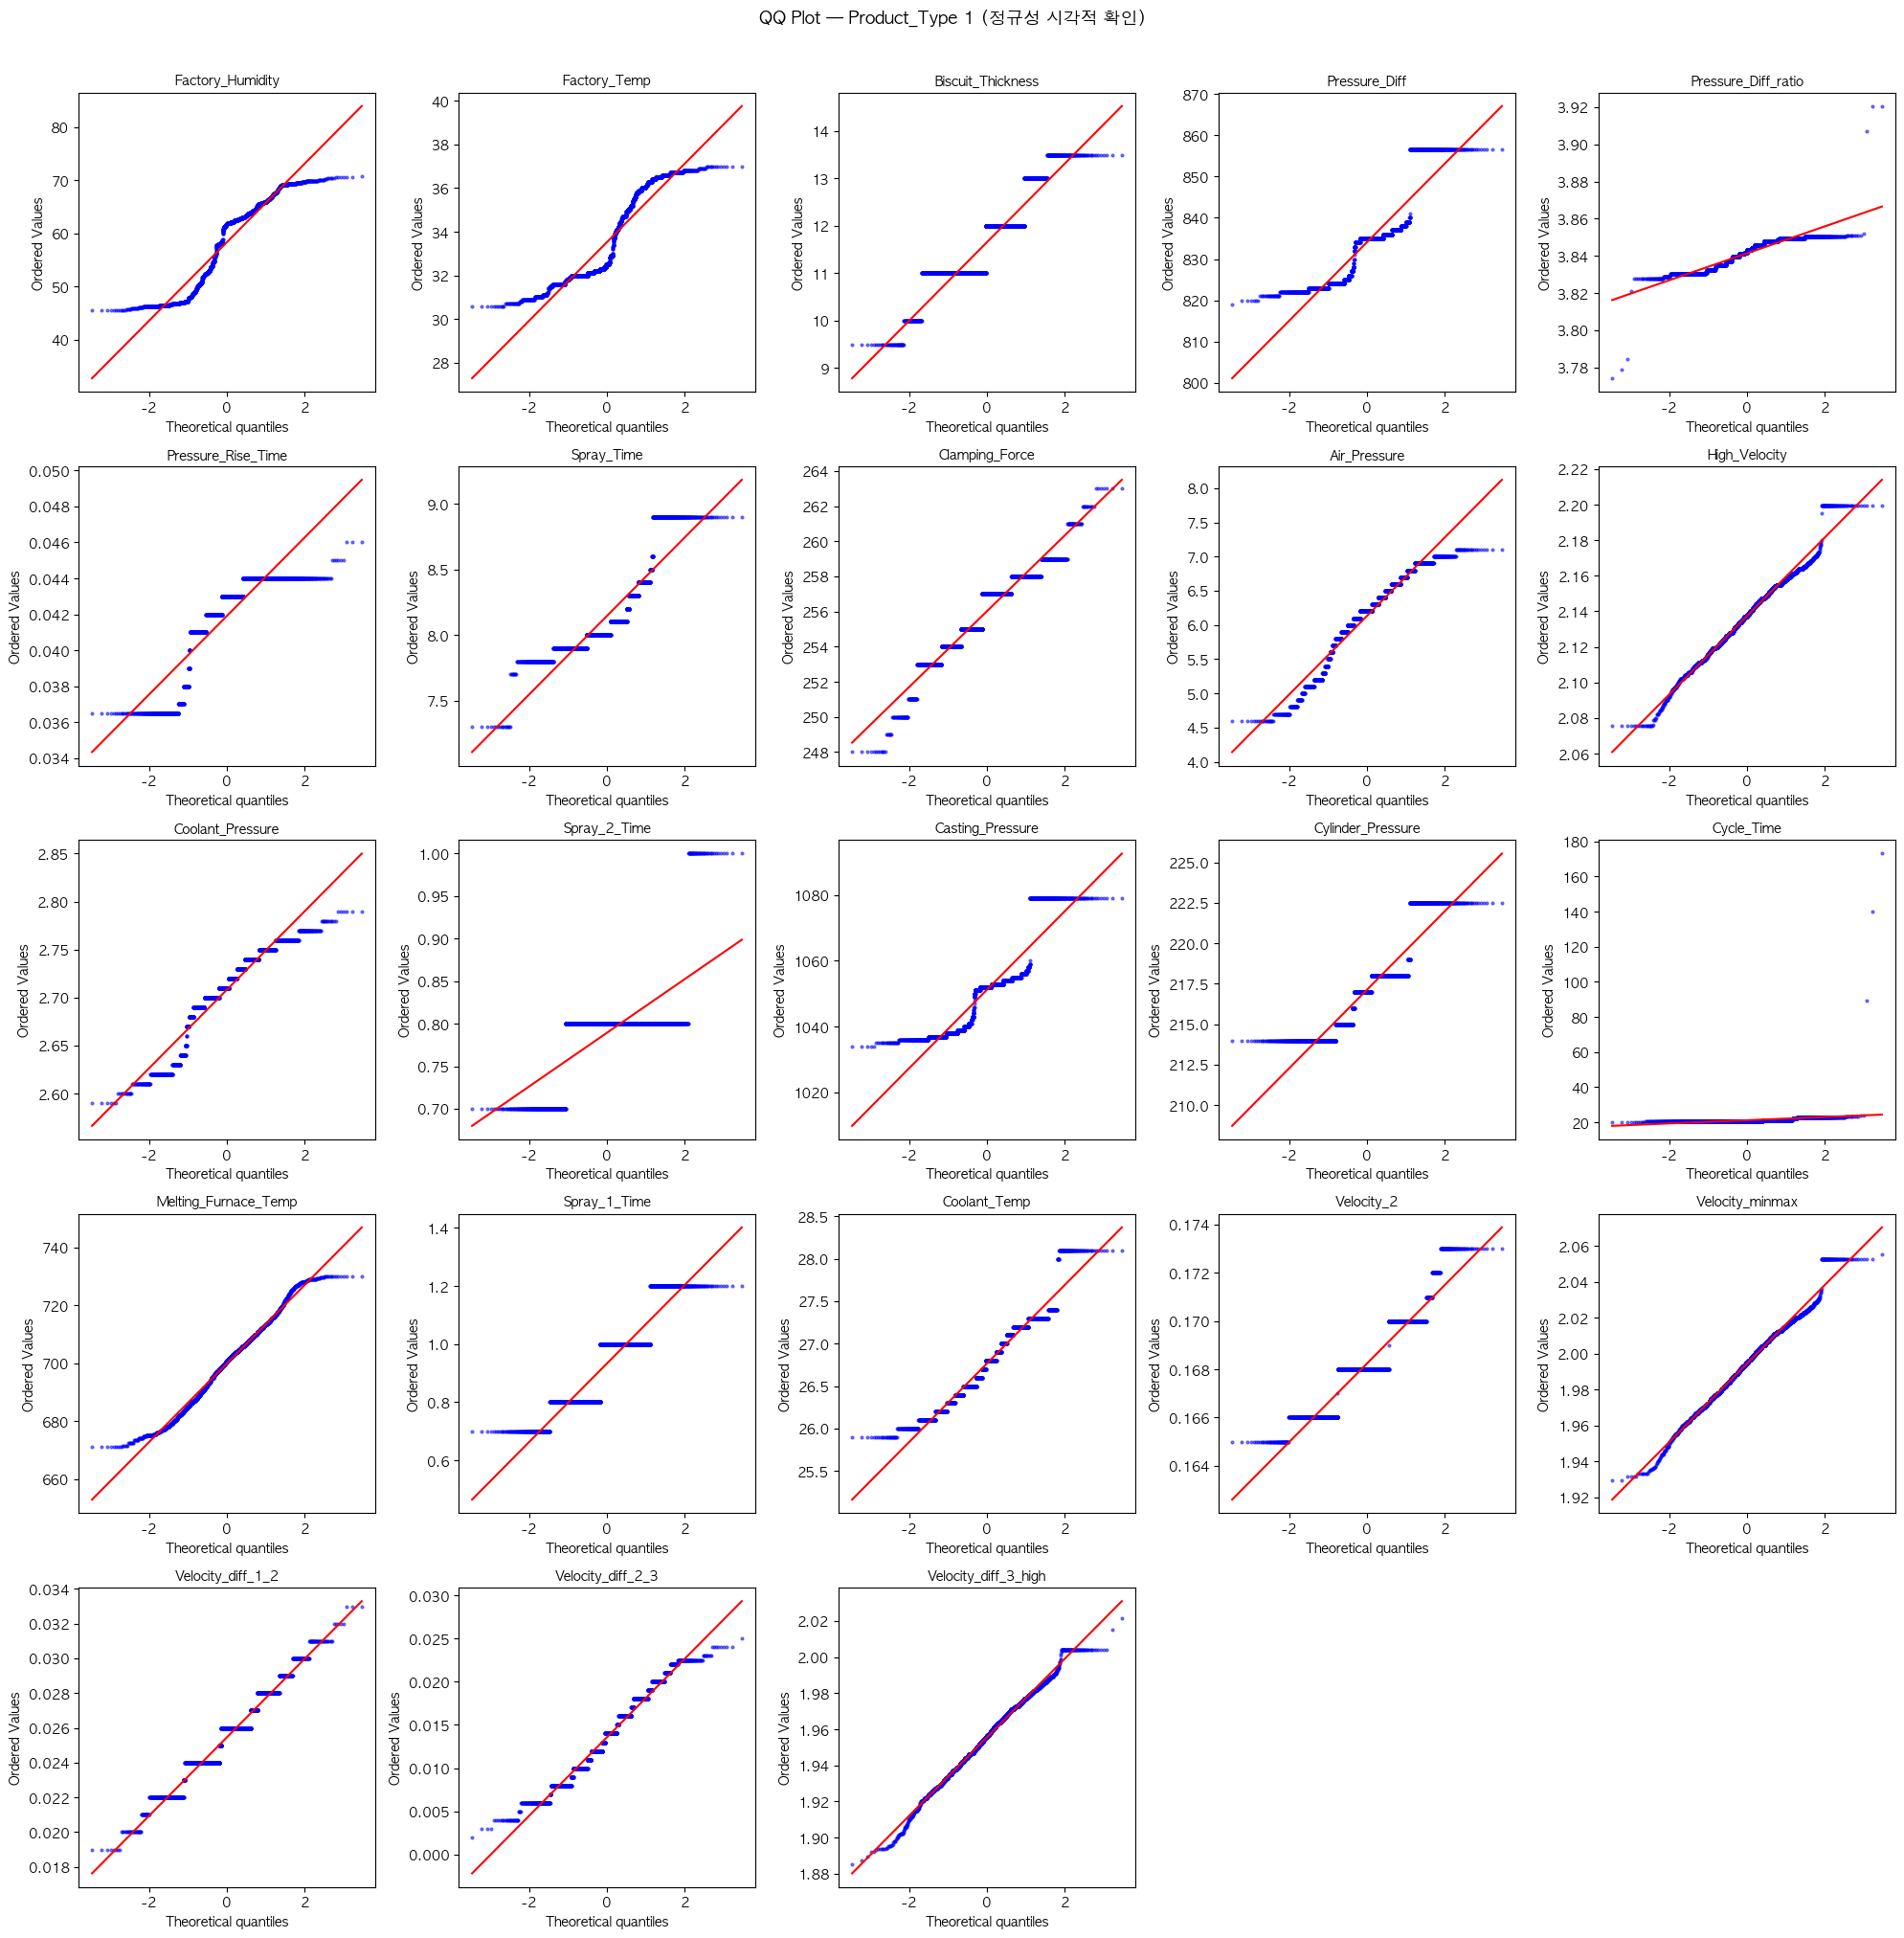

In [27]:
#---------------------
# 1-2. QQ Plot
#---------------------

import scipy.stats as stats
import matplotlib.pyplot as plt
import math

n_vars = len(target_vars)
n_cols = 5
n_rows = math.ceil(n_vars / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(target_vars):
    stats.probplot(type1_df[col].dropna(), dist="norm", plot=axes[i])
    axes[i].set_title(col, fontsize=10, fontweight='bold')
    axes[i].get_lines()[0].set(markersize=2, alpha=0.5)

# 남는 빈 서브플롯 숨기기
for j in range(n_vars, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('QQ Plot — Product_Type 1 (정규성 시각적 확인)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

In [28]:
#---------------------
# 2. Mann-Whitney U 검정
#---------------------

from scipy.stats import mannwhitneyu

defect   = type1_df[type1_df['Defect_Status'] == 1]
normal   = type1_df[type1_df['Defect_Status'] == 0]

results = []
for col in target_vars:
    stat, p = mannwhitneyu(
        defect[col].dropna(),
        normal[col].dropna(),
        alternative='two-sided'
    )
    results.append({
        '변수': col,
        'U통계량': round(stat, 1),
        'p-value': round(p, 4),
        '유의성': '✅' if p < 0.05 else '❌'
    })

result_df = pd.DataFrame(results).sort_values('p-value')
print(result_df.to_string(index=False))

                  변수     U통계량  p-value 유의성
    Factory_Humidity 364863.5   0.0000   ✅
          Cycle_Time 498077.5   0.0000   ✅
   Cylinder_Pressure 498957.0   0.0000   ✅
    Casting_Pressure 493165.5   0.0000   ✅
      Clamping_Force 662918.5   0.0000   ✅
          Spray_Time 518244.0   0.0000   ✅
        Spray_2_Time 686708.5   0.0000   ✅
 Pressure_Diff_ratio 514905.5   0.0000   ✅
       Pressure_Diff 491771.5   0.0000   ✅
   Biscuit_Thickness 464880.0   0.0000   ✅
        Factory_Temp 777645.0   0.0000   ✅
  Pressure_Rise_Time 678184.5   0.0000   ✅
Melting_Furnace_Temp 533220.0   0.0001   ✅
        Air_Pressure 658564.5   0.0002   ✅
       High_Velocity 658198.5   0.0002   ✅
Velocity_diff_3_high 656406.5   0.0003   ✅
     Velocity_minmax 654002.5   0.0005   ✅
   Velocity_diff_1_2 557762.5   0.0124   ✅
        Spray_1_Time 635366.5   0.0126   ✅
    Coolant_Pressure 562304.0   0.0292   ✅
        Coolant_Temp 562870.0   0.0321   ✅
          Velocity_2 565800.5   0.0355   ✅
   Velocity

In [29]:
#---------------------
# 3. 효과크기 계산 (Rank-Biserial Correlation)
#---------------------

from scipy.stats import mannwhitneyu
import numpy as np

def rank_biserial(u_stat, n1, n2):
    return (2 * u_stat) / (n1 * n2) - 1

defect = type1_df[type1_df['Defect_Status'] == 1]
normal = type1_df[type1_df['Defect_Status'] == 0]
n1, n2 = len(defect), len(normal)

results = []
for col in target_vars:
    stat, p = mannwhitneyu(defect[col].dropna(), normal[col].dropna(), alternative='two-sided')
    r = abs(rank_biserial(stat, n1, n2))
    results.append({
        '변수': col,
        'p-value': round(p, 4),
        '효과크기(r)': round(r, 4),
        '해석': '대' if r >= 0.5 else '중' if r >= 0.3 else '소'
    })

result_df = pd.DataFrame(results).sort_values('효과크기(r)', ascending=False)
print(result_df.to_string(index=False))

                  변수  p-value  효과크기(r) 해석
    Factory_Humidity   0.0000   0.3895  중
        Factory_Temp   0.0000   0.3013  중
   Biscuit_Thickness   0.0000   0.2221  소
       Pressure_Diff   0.0000   0.1771  소
    Casting_Pressure   0.0000   0.1748  소
          Cycle_Time   0.0000   0.1665  소
   Cylinder_Pressure   0.0000   0.1651  소
        Spray_2_Time   0.0000   0.1491  소
 Pressure_Diff_ratio   0.0000   0.1384  소
  Pressure_Rise_Time   0.0000   0.1348  소
          Spray_Time   0.0000   0.1328  소
      Clamping_Force   0.0000   0.1093  소
Melting_Furnace_Temp   0.0001   0.1077  소
        Air_Pressure   0.0002   0.1020  소
       High_Velocity   0.0002   0.1014  소
Velocity_diff_3_high   0.0003   0.0984  소
     Velocity_minmax   0.0005   0.0944  소
   Velocity_diff_1_2   0.0124   0.0667  소
        Spray_1_Time   0.0126   0.0632  소
    Coolant_Pressure   0.0292   0.0591  소
        Coolant_Temp   0.0321   0.0581  소
          Velocity_2   0.0355   0.0532  소
   Velocity_diff_2_3   0.2723   0.

In [30]:
#---------------------
# 4. Kruskal-Wallis H 검정 (Defect_Type별 차이
#---------------------

from scipy.stats import kruskal

defect_types = ['Exfoliation', 'Short_Shot', 'Deformation', 'Bubble', 'Normal']

results = []
for col in target_vars:
    groups = [type1_df[type1_df['Defect_Type'] == dt][col].dropna() for dt in defect_types]
    stat, p = kruskal(*groups)
    results.append({
        '변수': col,
        'H통계량': round(stat, 2),
        'p-value': round(p, 4),
        '유의성': '✅' if p < 0.05 else '❌'
    })

result_df = pd.DataFrame(results).sort_values('p-value')
print(result_df.to_string(index=False))

                  변수   H통계량  p-value 유의성
    Factory_Humidity 273.35   0.0000   ✅
        Coolant_Temp  71.79   0.0000   ✅
        Spray_1_Time  37.69   0.0000   ✅
Melting_Furnace_Temp  28.79   0.0000   ✅
          Cycle_Time  44.95   0.0000   ✅
   Cylinder_Pressure  40.74   0.0000   ✅
    Casting_Pressure  44.23   0.0000   ✅
    Coolant_Pressure  45.27   0.0000   ✅
        Spray_2_Time  73.60   0.0000   ✅
          Spray_Time  34.69   0.0000   ✅
  Pressure_Rise_Time  29.81   0.0000   ✅
 Pressure_Diff_ratio  26.90   0.0000   ✅
       Pressure_Diff  45.42   0.0000   ✅
   Biscuit_Thickness  76.29   0.0000   ✅
        Factory_Temp 221.14   0.0000   ✅
       High_Velocity  22.03   0.0002   ✅
Velocity_diff_3_high  21.39   0.0003   ✅
      Clamping_Force  20.38   0.0004   ✅
     Velocity_minmax  20.65   0.0004   ✅
        Air_Pressure  16.35   0.0026   ✅
          Velocity_2   9.22   0.0558   ❌
   Velocity_diff_1_2   7.01   0.1351   ❌
   Velocity_diff_2_3   2.30   0.6815   ❌


In [31]:
#---------------------
# 5. 효과크기 계산 (Epsilon-squared)
#---------------------

from scipy.stats import kruskal

defect_types = ['Exfoliation', 'Short_Shot', 'Deformation', 'Bubble', 'Normal']
n_total = len(type1_df)

results = []
for col in target_vars:
    groups = [type1_df[type1_df['Defect_Type'] == dt][col].dropna() for dt in defect_types]
    stat, p = kruskal(*groups)
    
    # epsilon-squared = H / (n - 1) / (n + 1) * n
    eps_sq = stat / (n_total - 1)
    
    results.append({
        '변수': col,
        'H통계량': round(stat, 2),
        'p-value': round(p, 4),
        'ε²': round(eps_sq, 4),
        '해석': '대' if eps_sq >= 0.14 else '중' if eps_sq >= 0.06 else '소'
    })

result_df = pd.DataFrame(results).sort_values('ε²', ascending=False)
print(result_df.to_string(index=False))

                  변수   H통계량  p-value     ε² 해석
    Factory_Humidity 273.35   0.0000 0.1032  중
        Factory_Temp 221.14   0.0000 0.0834  중
   Biscuit_Thickness  76.29   0.0000 0.0288  소
        Spray_2_Time  73.60   0.0000 0.0278  소
        Coolant_Temp  71.79   0.0000 0.0271  소
    Coolant_Pressure  45.27   0.0000 0.0171  소
       Pressure_Diff  45.42   0.0000 0.0171  소
          Cycle_Time  44.95   0.0000 0.0170  소
    Casting_Pressure  44.23   0.0000 0.0167  소
   Cylinder_Pressure  40.74   0.0000 0.0154  소
        Spray_1_Time  37.69   0.0000 0.0142  소
          Spray_Time  34.69   0.0000 0.0131  소
  Pressure_Rise_Time  29.81   0.0000 0.0112  소
Melting_Furnace_Temp  28.79   0.0000 0.0109  소
 Pressure_Diff_ratio  26.90   0.0000 0.0102  소
       High_Velocity  22.03   0.0002 0.0083  소
Velocity_diff_3_high  21.39   0.0003 0.0081  소
     Velocity_minmax  20.65   0.0004 0.0078  소
      Clamping_Force  20.38   0.0004 0.0077  소
        Air_Pressure  16.35   0.0026 0.0062  소
          Vel

In [20]:
#---------------------
# 6. 사후검정 (Dunn's Test)
#---------------------
import scikit_posthocs as sp

defect_types_list = ['Exfoliation', 'Short_Shot', 'Deformation', 'Bubble', 'Normal']

for col in final_vars:
    print(f'\n--- {col} ---')
    dunn = sp.posthoc_dunn(
        type1_df[type1_df['Defect_Type'].isin(defect_types_list)],
        val_col=col,
        group_col='Defect_Type',
        p_adjust='bonferroni'
    )
    print(dunn.round(4))


--- Factory_Humidity ---
             Bubble  Deformation  Exfoliation  Normal  Short_Shot
Bubble       1.0000       0.1854       0.0126     0.0      0.1318
Deformation  0.1854       1.0000       0.0000     0.0      0.0000
Exfoliation  0.0126       0.0000       1.0000     0.0      1.0000
Normal       0.0000       0.0000       0.0000     1.0      0.0000
Short_Shot   0.1318       0.0000       1.0000     0.0      1.0000

--- Factory_Temp ---
             Bubble  Deformation  Exfoliation  Normal  Short_Shot
Bubble       1.0000       0.3625       0.0000  0.0000      0.0156
Deformation  0.3625       1.0000       0.0000  0.0000      0.0000
Exfoliation  0.0000       0.0000       1.0000  1.0000      0.4445
Normal       0.0000       0.0000       1.0000  1.0000      0.0005
Short_Shot   0.0156       0.0000       0.4445  0.0005      1.0000

--- Biscuit_Thickness ---
             Bubble  Deformation  Exfoliation  Normal  Short_Shot
Bubble       1.0000          1.0          1.0  0.3426      1.0000
D